<a href="https://colab.research.google.com/github/weloo11/mnist-image-classifier/blob/main/mlp1(PCA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data(path="mnist.npz")


In [29]:
X = np.concatenate([x_train, x_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

In [30]:
print("Image data shape:", X.shape) #how many images you have
print("Label shape:", y.shape)  #whether each image is really 28×28
print("Unique labels:", np.unique(y)) #whether all labels are present

Image data shape: (70000, 28, 28)
Label shape: (70000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


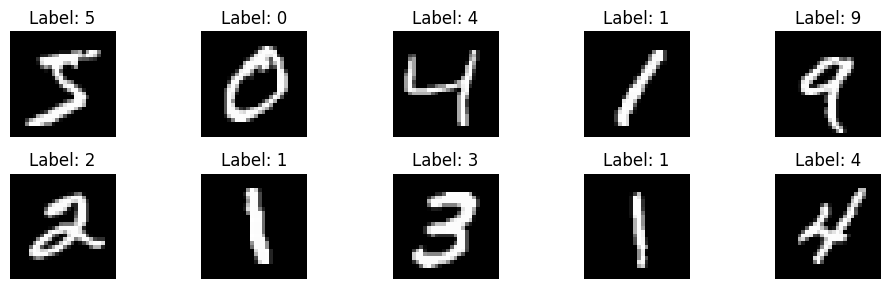

In [31]:
plt.figure(figsize=(10, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [32]:
TARGET_DIGIT = 5
y_binary = (y == TARGET_DIGIT).astype(int)

In [33]:
num_positive = np.sum(y_binary == 1)
num_negative = np.sum(y_binary == 0)

print("Target digit:", TARGET_DIGIT)
print("Positive samples (target class):", num_positive)
print("Negative samples (not target):", num_negative)
print("Positive ratio:", num_positive / len(y_binary))
print("Negative ratio:", num_negative / len(y_binary))

Target digit: 5
Positive samples (target class): 6313
Negative samples (not target): 63687
Positive ratio: 0.09018571428571429
Negative ratio: 0.9098142857142857


In [34]:
X = X.astype("float32") / 255.0 #Normalize image pixel values

In [35]:
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

Min pixel value: 0.0
Max pixel value: 1.0


In [36]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_binary,
    test_size=0.30,
    random_state=42,
    stratify=y_binary
)

Why stratify=y_binary is very important

Because your classes are imbalanced.

Stratification ensures each split keeps roughly the same proportion of:

target digit
not target digit

Without stratification, one split might accidentally contain too few positive examples.


In [37]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [38]:
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (49000, 28, 28) (49000,)
Validation shape: (10500, 28, 28) (10500,)
Test shape: (10500, 28, 28) (10500,)


In [39]:
def print_class_distribution(name, labels):
    positives = np.sum(labels == 1)
    negatives = np.sum(labels == 0)
    total = len(labels)
    print(f"{name}:")
    print(f"  Positives = {positives} ({positives/total:.4f})")
    print(f"  Negatives = {negatives} ({negatives/total:.4f})")

print_class_distribution("Training set", y_train)
print_class_distribution("Validation set", y_val)
print_class_distribution("Test set", y_test)

Training set:
  Positives = 4419 (0.0902)
  Negatives = 44581 (0.9098)
Validation set:
  Positives = 947 (0.0902)
  Negatives = 9553 (0.9098)
Test set:
  Positives = 947 (0.0902)
  Negatives = 9553 (0.9098)


In [40]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)
print("Flattened training shape:", X_train_flat.shape)
print("Flattened validation shape:", X_val_flat.shape)
print("Flattened test shape:", X_test_flat.shape)


Flattened training shape: (49000, 784)
Flattened validation shape: (10500, 784)
Flattened test shape: (10500, 784)


In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled   = scaler.transform(X_val_flat)
X_test_scaled  = scaler.transform(X_test_flat)

In [42]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Reduced number of features:", X_train_pca.shape[1])
print("Explained variance kept:", np.sum(pca.explained_variance_ratio_))

print("Preprocessing complete with PCA.")
print("PCA training data shape:", X_train_pca.shape)
print("PCA validation data shape:", X_val_pca.shape)
print("PCA test data shape:", X_test_pca.shape)

Original number of features: 784
Reduced number of features: 325
Explained variance kept: 0.9503117
Preprocessing complete with PCA.
PCA training data shape: (49000, 325)
PCA validation data shape: (10500, 325)
PCA test data shape: (10500, 325)


In [43]:
# Save PCA features
np.save("X_train_pca.npy", X_train_pca)
np.save("X_val_pca.npy", X_val_pca)
np.save("X_test_pca.npy", X_test_pca)

# Save labels
np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

print("PCA features and labels saved as .npy files.")

PCA features and labels saved as .npy files.
